<a href="https://www.kaggle.com/code/devendrarajpurohit58/centrallimittheorem?scriptVersionId=310433666" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
train_df=pd.read_csv("/kaggle/input/titanic/train.csv")
test_df=pd.read_csv("/kaggle/input/titanic/test.csv")

In [3]:
#Understanding CLT through Fare column
df=pd.concat([train_df.drop(columns=['Survived']),test_df]).sample(1309)

<Axes: ylabel='Density'>

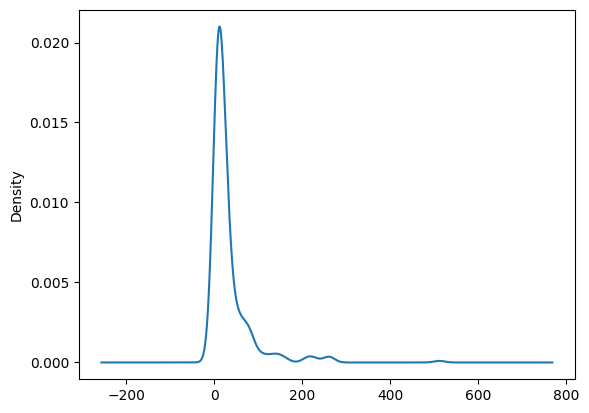

In [4]:
df['Fare'].plot(kind='kde')  # this can be considered as the population distribution of the fare column for now.

In [5]:
#take sample size as 50 and no. of samples is 1000
samples=[]
stds=[]
for i in range(10):
    x=df['Fare'].dropna().sample(30).values
    stds.append(x.std())
    samples.append(x.tolist())

In [6]:
samples=np.array(samples)

In [7]:
sampling_means=samples.mean(axis=1)

In [8]:
sample_std=np.mean(stds)

<Axes: ylabel='Density'>

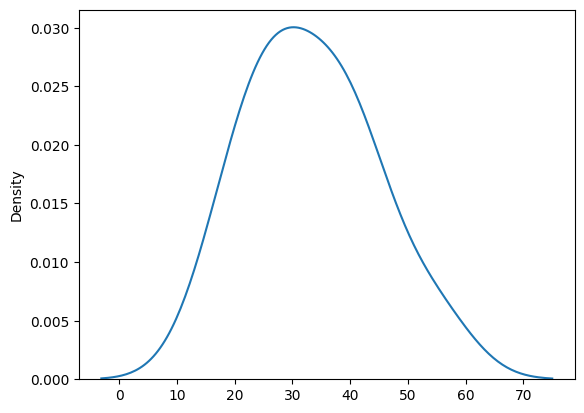

In [9]:
import seaborn as sns
sns.kdeplot(sampling_means)#we see that the plot of this means resembles normal distribution

In [10]:
mean_of_sample=sampling_means.mean()

In [11]:
#there is an approximation to the values of means of both population and sample.
#so we determine confidence intervals stating mean would be in this interval

sampling_means.std()/np.sqrt(50)

np.float64(1.4772062922759033)

In [12]:
lower_limit=sampling_means.mean() - 2.042*(sample_std/np.sqrt(50))#2.042 facotr is used as it corresponds to value for 90% confidence for 30 sample size
upper_limit=sampling_means.mean() + 2.042*(sample_std/np.sqrt(50))

In [13]:
lower_limit

np.float64(20.85060279655028)

In [14]:
upper_limit

np.float64(45.67498120344973)

In [15]:
df['Fare'].mean() #our mean lies between the confidence intervals (lower_limit and upper_limit)

np.float64(33.295479281345564)

### **The code in this notebook is also an exmaple of t-procedure to calculate the Confidence interval for a given confidence level.Sample standard deviation is considered for the calculation(mean of standard deviation of all the samples. In this case 100 samples)**